In [1]:
import os
import cv2
import glob
import random
import numpy as np
import xml.etree.ElementTree as ET

from tqdm import tqdm
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import shuffle

In [2]:
BASE_DIR = "/kaggle/input/inriaperson"

TRAIN_IMG_DIR = os.path.join(BASE_DIR, "Train/JPEGImages")
TRAIN_ANN_DIR = os.path.join(BASE_DIR, "Train/Annotations")

TEST_IMG_DIR = os.path.join(BASE_DIR, "Test/JPEGImages")
TEST_ANN_DIR = os.path.join(BASE_DIR, "Test/Annotations")

WINDOW_SIZE = (64, 128)

In [3]:
hog = cv2.HOGDescriptor(
    _winSize=WINDOW_SIZE,
    _blockSize=(16,16),
    _blockStride=(8,8),
    _cellSize=(8,8),
    _nbins=9
)

In [4]:
def extract_positive_samples(img_dir, ann_dir):
    samples = []
    
    for ann_file in tqdm(glob.glob(os.path.join(ann_dir, "*.xml"))):
        tree = ET.parse(ann_file)
        root = tree.getroot()
        
        filename = root.find("filename").text
        img_path = os.path.join(img_dir, filename)

        if not os.path.exists(img_path):
            # try changing extension
            alt = filename.replace(".png", ".jpg")
            img_path = os.path.join(img_dir, alt)
             
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        for obj in root.findall("object"):
            name = obj.find("name").text.lower()
            
            if "person" not in name:
                continue
            
            bndbox = obj.find("bndbox")
            xmin = int(float(bndbox.find("xmin").text))
            ymin = int(float(bndbox.find("ymin").text))
            xmax = int(float(bndbox.find("xmax").text))
            ymax = int(float(bndbox.find("ymax").text))
            
            crop = img[ymin:ymax, xmin:xmax]
            if crop.size == 0:
                continue
            
            crop = cv2.resize(crop, WINDOW_SIZE)
            samples.append(crop)
    
    return samples

In [5]:
def compute_hog_features(images):
    features = []
    
    for img in tqdm(images):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        feat = hog.compute(gray)
        features.append(feat.flatten())
    
    return np.array(features)

In [6]:
from PIL import Image

def robust_imread(path):
    img = cv2.imread(path)
    if img is not None:
        return img
    
    # fallback via PIL
    pil_img = Image.open(path).convert("RGB")
    img = np.array(pil_img)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    return img


In [7]:
def get_all_negative_images(neg_dir):
    extensions = ["*.jpg", "*.jpeg", "*.png", "*.webp", "*.avif",
                  "*.JPG", "*.JPEG", "*.PNG", "*.WEBP", "*.AVIF"]
    
    paths = []
    for ext in extensions:
        paths.extend(glob.glob(os.path.join(neg_dir, ext)))
    
    return paths


NEG_DIR = "/kaggle/input/datasets/piwoobeep/negative-pedestrians/negative-pedestrains"
neg_image_paths = get_all_negative_images(NEG_DIR)

print("Total negative images found:", len(neg_image_paths))

Total negative images found: 72


In [11]:
def extract_negatives_from_custom_set(image_paths, crops_per_image=15):
    samples = []
    
    for path in tqdm(image_paths):
        img = robust_imread(path)
        if img is None:
            continue
        
        h, w = img.shape[:2]
        
        if w < WINDOW_SIZE[0] or h < WINDOW_SIZE[1]:
            continue
        
        for _ in range(crops_per_image):
            x = random.randint(0, w - WINDOW_SIZE[0])
            y = random.randint(0, h - WINDOW_SIZE[1])
            
            crop = img[y:y+WINDOW_SIZE[1], x:x+WINDOW_SIZE[0]]
            samples.append(crop)
    
    print("Custom negative samples:", len(samples))
    return samples

In [12]:
print("Extracting positive samples...")
pos_train = extract_positive_samples(TRAIN_IMG_DIR, TRAIN_ANN_DIR)

print("Extracting negative samples...")
neg_train = extract_negatives_from_custom_set(neg_image_paths, crops_per_image=15)

print("Computing HOG features...")
X_pos = compute_hog_features(pos_train)
X_neg = compute_hog_features(neg_train)

y_pos = np.ones(len(X_pos))
y_neg = np.zeros(len(X_neg))

X_train = np.vstack((X_pos, X_neg))
y_train = np.hstack((y_pos, y_neg))

X_train, y_train = shuffle(X_train, y_train, random_state=42)

print("Training samples:", X_train.shape)

Extracting positive samples...


100%|██████████| 614/614 [00:36<00:00, 16.67it/s]


Extracting negative samples...


100%|██████████| 72/72 [00:02<00:00, 34.27it/s]


Custom negative samples: 1080
Computing HOG features...


100%|██████████| 1080/1080 [00:00<00:00, 3720.30it/s]


Training samples: (2320, 3780)


In [13]:
min_count = min(len(X_pos), len(X_neg))

X_pos_bal = X_pos[:min_count]
X_neg_bal = X_neg[:min_count]

y_pos = np.ones(min_count)
y_neg = np.zeros(min_count)

X_train = np.vstack((X_pos_bal, X_neg_bal))
y_train = np.hstack((y_pos, y_neg))

X_train, y_train = shuffle(X_train, y_train, random_state=42)

print("Final training shape:", X_train.shape)

Final training shape: (2160, 3780)


In [17]:
print("Extracting test positives...")
pos_test = extract_positive_samples(TEST_IMG_DIR, TEST_ANN_DIR)

print("Extracting test negatives...")
neg_test = extract_negatives_from_custom_set(neg_image_paths, crops_per_image=10)


Extracting test positives...


100%|██████████| 288/288 [00:07<00:00, 38.55it/s]


Extracting test negatives...


100%|██████████| 72/72 [00:01<00:00, 50.70it/s] 


Custom negative samples: 720


100%|██████████| 720/720 [00:00<00:00, 3652.53it/s]


In [18]:

X_pos_test = compute_hog_features(pos_test)
X_neg_test = compute_hog_features(neg_test)

min_test = min(len(X_pos_test), len(X_neg_test))

X_test = np.vstack((X_pos_test[:min_test], X_neg_test[:min_test]))
y_test = np.hstack((np.ones(min_test), np.zeros(min_test)))

100%|██████████| 720/720 [00:00<00:00, 3573.81it/s]


In [19]:
def detect_pedestrians(image, svm, step_size=8, scale=1.25, threshold=0.3):
    detections = []
    scores = []
    
    img = image.copy()
    current_scale = 1.0
    
    while img.shape[0] >= WINDOW_SIZE[1] and img.shape[1] >= WINDOW_SIZE[0]:
        
        for y in range(0, img.shape[0] - WINDOW_SIZE[1], step_size):
            for x in range(0, img.shape[1] - WINDOW_SIZE[0], step_size):
                
                window = img[y:y+WINDOW_SIZE[1], x:x+WINDOW_SIZE[0]]
                gray = cv2.cvtColor(window, cv2.COLOR_BGR2GRAY)
                feat = hog.compute(gray).flatten().reshape(1, -1)
                
                score = svm.decision_function(feat)[0]
                
                if score > threshold:
                    x1 = int(x * (1/current_scale))
                    y1 = int(y * (1/current_scale))
                    w = int(WINDOW_SIZE[0] * (1/current_scale))
                    h = int(WINDOW_SIZE[1] * (1/current_scale))
                    
                    detections.append([x1, y1, x1+w, y1+h])
                    scores.append(score)
        
        current_scale *= scale
        img = cv2.resize(image, None, fx=1/current_scale, fy=1/current_scale)
    
    return detections, scores

In [20]:
def non_max_suppression(boxes, scores, overlapThresh=0.3):
    if len(boxes) == 0:
        return []
    
    boxes = np.array(boxes)
    scores = np.array(scores)
    
    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,2]
    y2 = boxes[:,3]
    
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]
    
    keep = []
    
    while order.size > 0:
        i = order[0]
        keep.append(i)
        
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        
        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)
        
        inter = w * h
        ovr = inter / (areas[i] + areas[order[1:]] - inter)
        
        inds = np.where(ovr <= overlapThresh)[0]
        order = order[inds + 1]
    
    return boxes[keep]

In [14]:
svm = LinearSVC(C=0.01, max_iter=20000)

print("Training SVM...")
svm.fit(X_train, y_train)

Training SVM...


LinearSVC(C=0.01, max_iter=20000)

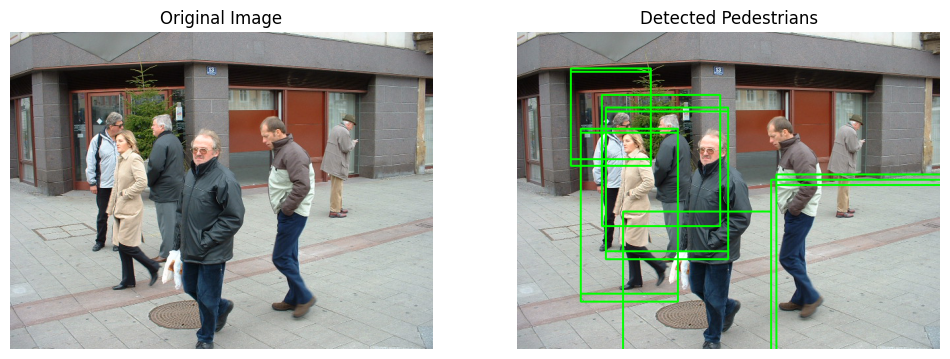

In [185]:
import matplotlib.pyplot as plt

# Pick one test image
test_img_paths = glob.glob(os.path.join(TEST_IMG_DIR, "*.png")) + \
                 glob.glob(os.path.join(TEST_IMG_DIR, "*.jpg"))

sample_path = random.choice(test_img_paths)
original = cv2.imread(sample_path)

detections, scores = detect_pedestrians(original, svm, threshold=0.95)

final_boxes = non_max_suppression(detections, scores)

marked = original.copy()

for (x1, y1, x2, y2) in final_boxes:
    cv2.rectangle(marked, (x1, y1), (x2, y2), (0,255,0), 2)

marked = original.copy()

for (x, y, w, h) in detections:
    cv2.rectangle(marked, (x, y), (x+w, y+h), (0,255,0), 2)

# Convert BGR to RGB for matplotlib
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
marked_rgb = cv2.cvtColor(marked, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(marked_rgb)
plt.title("Detected Pedestrians")
plt.axis("off")

plt.show()

In [23]:
y_pred = svm.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9639865996649917

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96       597
         1.0       0.98      0.95      0.96       597

    accuracy                           0.96      1194
   macro avg       0.96      0.96      0.96      1194
weighted avg       0.96      0.96      0.96      1194


Confusion Matrix:
[[584  13]
 [ 30 567]]
